# Test Cartesian Kerr-Schild & RIAF Volumetric Rendering

This notebook tests the new CKS metric integrators and the RIAF disk mode.

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import sys
import os
sys.path.append(os.path.abspath('..'))
from nulltracer.renderer import CudaRenderer
import matplotlib.pyplot as plt
import numpy as np
import time
from PIL import Image
import io

In [2]:
# Initialize renderer
renderer = CudaRenderer()
renderer.initialize()

BL Thin disk render took: 1549.348575999943 ms


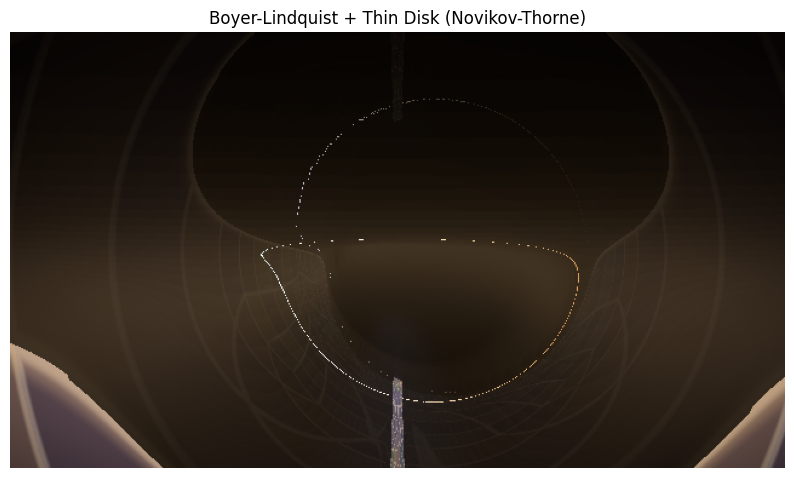

In [3]:
# Render parameters for standard Boyer-Lindquist Thin Disk
params_bl_thin = {
    "width": 640,
    "height": 360,
    "spin": 0.99,
    "charge": 0.0,
    "inclination": 85.0,
    "obs_dist": 40.0,
    "fov": 8.0,
    "method": "rkdp8",
    "disk_mode": 1,
    "show_disk": True,
    "disk_temp": 1.0,
    "doppler_boost": 1,
    "srgb_output": True,
    "bloom_enabled": False
}

start = time.time()
res_bl = renderer.render_frame_timed(params_bl_thin)
print(f"BL Thin disk render took: {res_bl['total_ms']} ms")

img_bl = np.frombuffer(res_bl['raw_rgb'], dtype=np.uint8).reshape((params_bl_thin['height'], params_bl_thin['width'], 3))
plt.figure(figsize=(10, 6))
plt.imshow(img_bl)
plt.title("Boyer-Lindquist + Thin Disk (Novikov-Thorne)")
plt.axis('off')
plt.show()

RIAF Volumetric render took: 189.33294299995396 ms


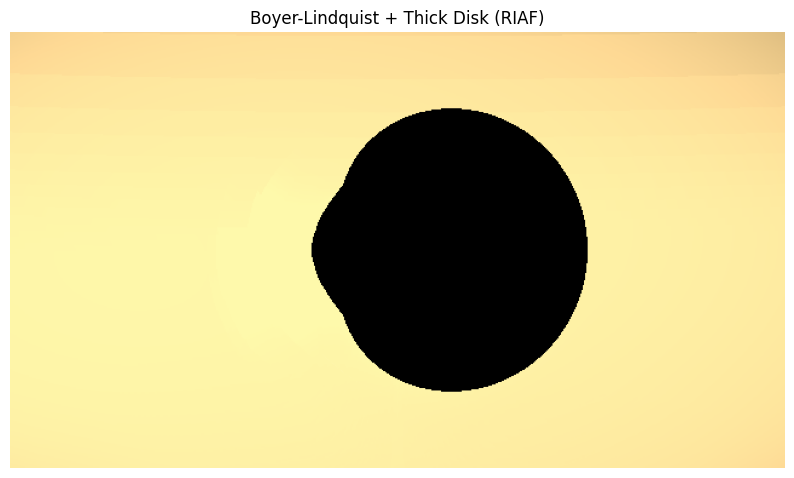

In [4]:
# Render parameters for Volumetric RIAF Disk
params_riaf = {
    "width": 640,
    "height": 360,
    "spin": 0.99,
    "charge": 0.0,
    "inclination": 85.0,
    "obs_dist": 40.0,
    "fov": 8.0,
    "method": "rkdp8",
    "disk_mode": 2,
    "show_disk": True,
    "disk_temp": 1.0,
    "doppler_boost": 1,
    "srgb_output": True,
    "bloom_enabled": False
}

start = time.time()
res_riaf = renderer.render_frame_timed(params_riaf)
print(f"RIAF Volumetric render took: {res_riaf['total_ms']} ms")

img_riaf = np.frombuffer(res_riaf['raw_rgb'], dtype=np.uint8).reshape((params_riaf['height'], params_riaf['width'], 3))
plt.figure(figsize=(10, 6))
plt.imshow(img_riaf)
plt.title("Boyer-Lindquist + Thick Disk (RIAF)")
plt.axis('off')
plt.show()

CKS RIAF Volumetric render took: 119.15641300004154 ms


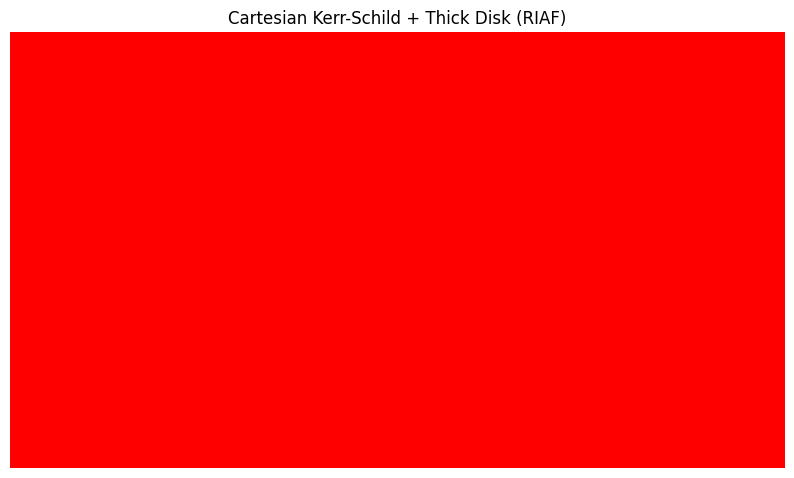

In [5]:
# Render parameters for CKS Metric + RIAF
params_cks_riaf = {
    "width": 640,
    "height": 360,
    "spin": 0.99,
    "charge": 0.0,
    "inclination": 85.0,
    "obs_dist": 40.0,
    "fov": 8.0,
    "method": "rkdp8_cks",
    "disk_mode": 2,
    "show_disk": True,
    "disk_temp": 1.0,
    "doppler_boost": 1,
    "srgb_output": True,
    "bloom_enabled": False
}

start = time.time()
res_cks = renderer.render_frame_timed(params_cks_riaf)
print(f"CKS RIAF Volumetric render took: {res_cks['total_ms']} ms")

img_cks = np.frombuffer(res_cks['raw_rgb'], dtype=np.uint8).reshape((params_cks_riaf['height'], params_cks_riaf['width'], 3))
plt.figure(figsize=(10, 6))
plt.imshow(img_cks)
plt.title("Cartesian Kerr-Schild + Thick Disk (RIAF)")
plt.axis('off')
plt.show()

CKS Thin disk render took: 0.6749469999931534 ms


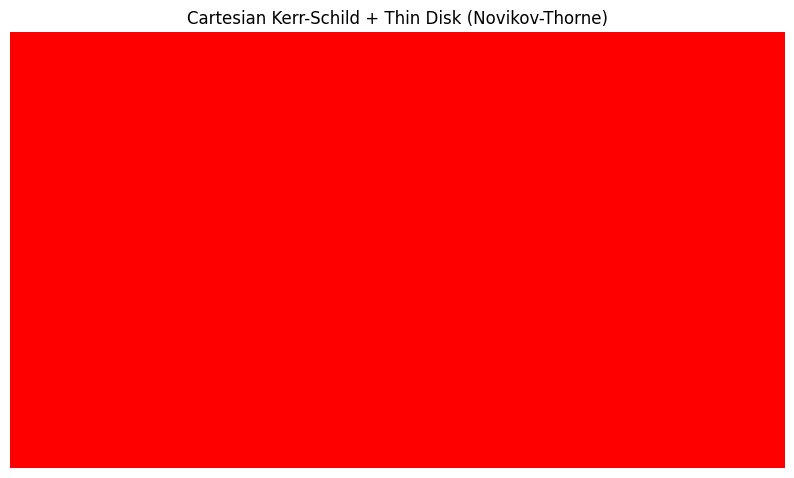

In [6]:
# Render parameters for CKS Metric + Thin Disk
params_cks_thin = {
    "width": 640,
    "height": 360,
    "spin": 0.99,
    "charge": 0.0,
    "inclination": 85.0,
    "obs_dist": 40.0,
    "fov": 8.0,
    "method": "rkdp8_cks",
    "disk_mode": 1,
    "show_disk": True,
    "disk_temp": 1.0,
    "doppler_boost": 1,
    "srgb_output": True,
    "bloom_enabled": False
}

start = time.time()
res_cks_thin = renderer.render_frame_timed(params_cks_thin)
print(f"CKS Thin disk render took: {res_cks_thin['total_ms']} ms")

img_cks_thin = np.frombuffer(res_cks_thin['raw_rgb'], dtype=np.uint8).reshape((params_cks_thin['height'], params_cks_thin['width'], 3))
plt.figure(figsize=(10, 6))
plt.imshow(img_cks_thin)
plt.title("Cartesian Kerr-Schild + Thin Disk (Novikov-Thorne)")
plt.axis('off')
plt.show()

CKS RK4 Thin disk render took: 152.44182300000375 ms


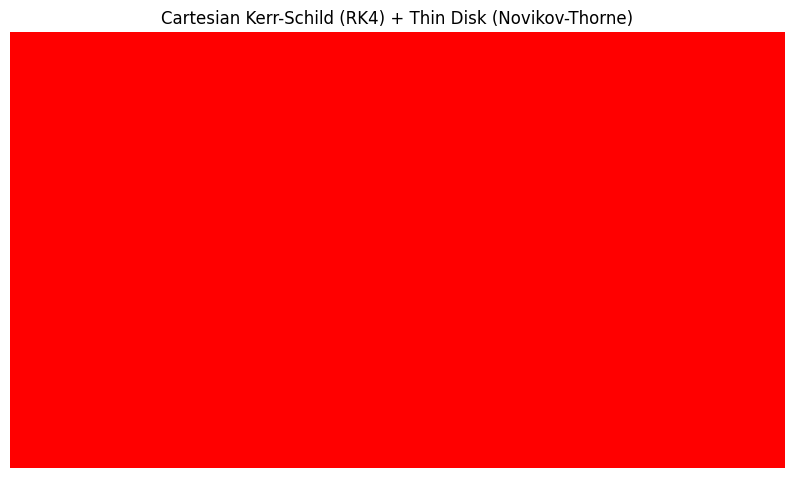

In [7]:
# Render parameters for CKS Metric + Thin Disk (RK4)
params_cks_rk4_thin = {
    "width": 640,
    "height": 360,
    "spin": 0.99,
    "charge": 0.0,
    "inclination": 85.0,
    "obs_dist": 40.0,
    "fov": 8.0,
    "method": "rk4_cks",
    "disk_mode": 1,
    "show_disk": True,
    "disk_temp": 1.0,
    "doppler_boost": 1,
    "srgb_output": True,
    "bloom_enabled": False
}

start = time.time()
res_cks_rk4_thin = renderer.render_frame_timed(params_cks_rk4_thin)
print(f"CKS RK4 Thin disk render took: {res_cks_rk4_thin['total_ms']} ms")

img_cks_rk4_thin = np.frombuffer(res_cks_rk4_thin['raw_rgb'], dtype=np.uint8).reshape((params_cks_rk4_thin['height'], params_cks_rk4_thin['width'], 3))
plt.figure(figsize=(10, 6))
plt.imshow(img_cks_rk4_thin)
plt.title("Cartesian Kerr-Schild (RK4) + Thin Disk (Novikov-Thorne)")
plt.axis('off')
plt.show()

CKS RK4 RIAF Volumetric render took: 0.9751370000685711 ms


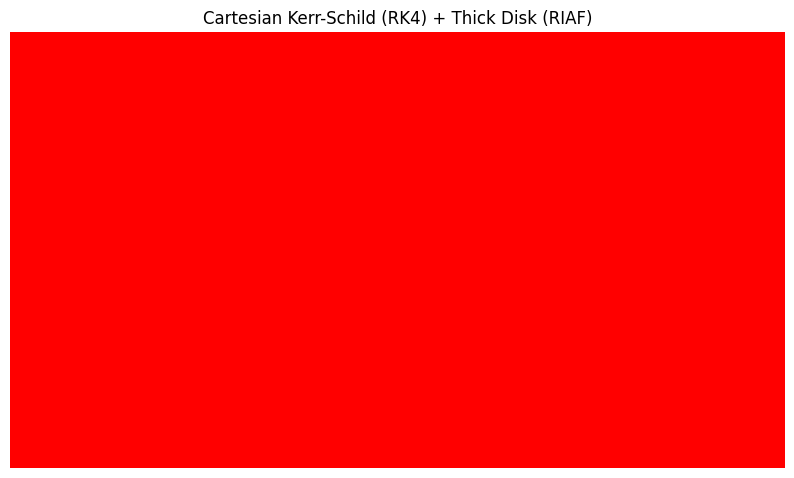

In [8]:
# Render parameters for CKS Metric + RIAF (RK4)
params_cks_rk4_riaf = {
    "width": 640,
    "height": 360,
    "spin": 0.99,
    "charge": 0.0,
    "inclination": 85.0,
    "obs_dist": 40.0,
    "fov": 8.0,
    "method": "rk4_cks",
    "disk_mode": 2,
    "show_disk": True,
    "disk_temp": 1.0,
    "doppler_boost": 1,
    "srgb_output": True,
    "bloom_enabled": False
}

start = time.time()
res_cks_rk4_riaf = renderer.render_frame_timed(params_cks_rk4_riaf)
print(f"CKS RK4 RIAF Volumetric render took: {res_cks_rk4_riaf['total_ms']} ms")

img_cks_rk4_riaf = np.frombuffer(res_cks_rk4_riaf['raw_rgb'], dtype=np.uint8).reshape((params_cks_rk4_riaf['height'], params_cks_rk4_riaf['width'], 3))
plt.figure(figsize=(10, 6))
plt.imshow(img_cks_rk4_riaf)
plt.title("Cartesian Kerr-Schild (RK4) + Thick Disk (RIAF)")
plt.axis('off')
plt.show()